In [13]:
import numpy as np
import pandas as pd

# Detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading.
# The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

X = np.load('initial_inputs.npy')
y = np.load('initial_outputs.npy')

print('-- inputs X ---')
print(X)
print("X shape=",X.shape)

print('-- outputs y ---')
print(y)
print("y shape=",y.shape)

-- inputs X ---
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]]
X shape= (10, 2)
-- outputs y ---
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048]
y shape= (10,)


In [14]:
df = pd.DataFrame(X, columns=["x1","x2"])
df['y'] = y
df = df.sort_values(by='y', ascending=False)
df

,x1,x2,y
2,0.731024,0.733000,7.710875e-16
7,0.683418,0.861057,2.535001e-40
1,0.574329,0.879898,1.033078e-46
9,0.883890,0.582254,6.229856e-48
0,0.319404,0.762959,1.322677e-79
8,0.082507,0.403488,3.606771e-81
3,0.840353,0.264732,3.341771e-124
6,0.312691,0.078723,-2.089093e-91
5,0.410437,0.147554,-2.159249e-54
4,0.650114,0.681526,-3.606063e-03


In [15]:
# Scientific Notation,Decimal Representation (Significant Figures)
1 # 1.32267704e-079,0.000...0001322 (78 zeros before the 1)
2 # 1.03307824e-046,0.000...0001033 (45 zeros before the 1)
3 # 7.71087511e-016,0.00000000000000077108 (15 zeros before the 7)   --> current largest point peak
4 # 3.34177101e-124,0.000...0003341 (123 zeros before the 3)
5 # -3.60606264e-003,-0.00360606264                       --> this is extreme pit
6 # -2.15924904e-054,-0.000...0002159 (53 zeros before the 2)
7 # -2.08909327e-091,-0.000...0002089 (90 zeros before the 2)
8 # 2.53500115e-040,0.000...0002535 (39 zeros before the 2)
9 # 3.60677119e-081,0.000...0003606 (80 zeros before the 3)
10 # 6.22985647e-048,0.000...0006229 (47 zeros before the 6)

10

In [17]:
df = pd.DataFrame(X, columns=["x1","x2"])
df['y'] = y
df = df.sort_values(by='y', ascending=False)
df.head(20)

,x1,x2,y
2,0.731024,0.733000,7.710875e-16
7,0.683418,0.861057,2.535001e-40
1,0.574329,0.879898,1.033078e-46
9,0.883890,0.582254,6.229856e-48
0,0.319404,0.762959,1.322677e-79
8,0.082507,0.403488,3.606771e-81
3,0.840353,0.264732,3.341771e-124
6,0.312691,0.078723,-2.089093e-91
5,0.410437,0.147554,-2.159249e-54
4,0.650114,0.681526,-3.606063e-03


In [18]:
import numpy as np
import warnings
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel
from sklearn.exceptions import ConvergenceWarning
import matplotlib.pyplot as plt
from scipy.stats import norm

# Put this at the very top of your script
warnings.filterwarnings('ignore', category=ConvergenceWarning)

kernel = Matern(nu=2.5, length_scale_bounds=(0.1, 1.0))
# kernel = ConstantKernel(1.0, (1e-5, 10)) * Matern(length_scale=[0.5, 0.5], length_scale_bounds=(1e-2, 1), nu=2.5)

# noise_assumption=1e-10 (default no noise) , 1e-6 (tiny noise) , 1e-3 (moderate noise) 
# noise_assumption=0.1
noise_assumption=1e-6

gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, alpha=noise_assumption, n_restarts_optimizer=5)
gp.fit(X, y)

print(f"Optimized Kernel: {gp.kernel_}")
print(f"Training R^2 Score: {gp.score(X, y)}")
print(f"Total variance accounted for as noise: {gp.alpha}")
print(f"Final length scale: {gp.kernel_.length_scale}")

# 1) week1
# Optimized Kernel: Matern(length_scale=0.1, nu=2.5)
# Training R^2 Score: 0.9999999999970315
# Total variance accounted for as noise: 1e-06
# Final length scale: 0.10000000000000002

Optimized Kernel: Matern(length_scale=0.1, nu=2.5)
Training R^2 Score: 0.9999999999970315
Total variance accounted for as noise: 1e-06
Final length scale: 0.10000000000000002


In [19]:
# UCB ACQUISITION FUNCTION
def upper_confidence_bound(mu, sigma, kappa=2.0):
    """
    kappa = 1.96  -> 95% confidence (Balanced)
    kappa = 2.576 -> 99% confidence (More Exploration)
    """
    return mu + kappa * sigma
    
def expected_improvement(mu, sigma, y_best, xi=0.01):
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei


# Create grid of potential X values
res=100
x_coord = np.linspace(0, 1, 100)
X1, X2 = np.meshgrid(x_coord, x_coord)
X_grid = np.vstack([X1.ravel(), X2.ravel()]).T

# Get predictions
mu, sigma = gp.predict(X_grid, return_std=True)

# sigma = sigma.reshape(-1, 1)
# mu = mu.reshape(-1, 1)
y_best = y.max()

In [21]:
kappa = 2
ucb_values = upper_confidence_bound(mu, sigma, kappa)

ucb_map = ucb_values.reshape(res, res)
mu_map = mu.reshape(res, res)

ucb_next_idx = np.argmax(ucb_values)
ucb_next_query = X_grid[ucb_next_idx]

print(f"--- Optimization Results ---")
print(f"UCB Score with kappa: {kappa}")
print(f"Current Best y: {y_best}")
print(f"Suggested next: {ucb_next_query}")

# 1)week 1
# --- Optimization Results ---
# UCB Score with kappa: 2
# Current Best y: 7.710875114502849e-16
# Suggested next: [0.82828283 0.77777778]


--- Optimization Results ---
UCB Score with kappa: 2
Current Best y: 7.710875114502849e-16
Suggested next: [0.82828283 0.77777778]


In [22]:
xi=0.01
ei_values = expected_improvement(mu, sigma, y_best, xi)

# Get the next best point
ei_next_idx = np.argmax(ei_values)
ei_next_query = X_grid[ei_next_idx]

print(f"--- Optimization Results ---")
print(f"expected_improvement with xi: {xi}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ei_next_query}")

# 1) week1
# --- Optimization Results ---
# expected_improvement with xi: 0.01
# Current Best y: 7.710875114502849e-16
# Suggested next: [0.90909091 0.81818182]

--- Optimization Results ---
expected_improvement with xi: 0.01
Current Best y: 7.710875114502849e-16
Suggested next: [0.90909091 0.81818182]


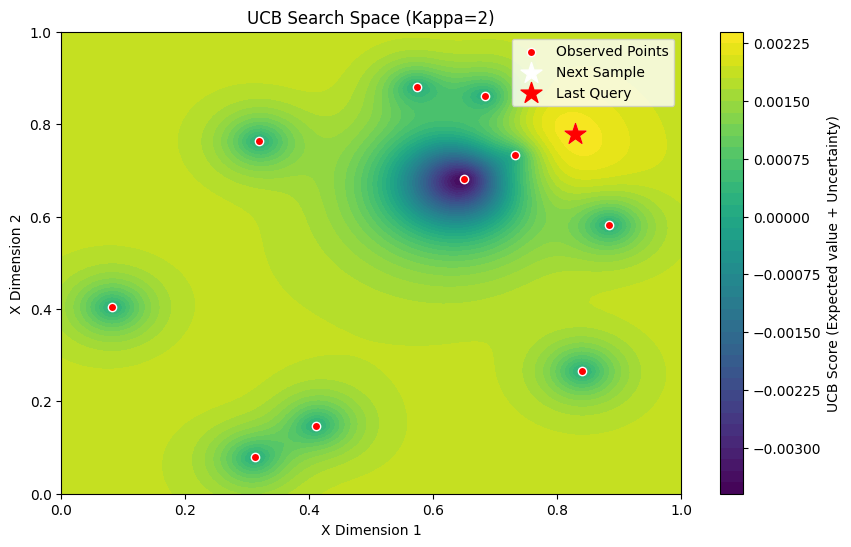

In [23]:
# VISUALIZATION
week1_query= [0.828282, 0.777777]
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, ucb_map, levels=50, cmap='viridis')
plt.colorbar(label='UCB Score (Expected value + Uncertainty)')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Observed Points')
plt.scatter(ucb_next_query[0], ucb_next_query[1], c='white', marker='*', s=250, label='Next Sample')
plt.scatter(week1_query[0], week1_query[1], c='red', marker='*', s=250, label='Last Query')
plt.title(f"UCB Search Space (Kappa={kappa})")
plt.xlabel("X Dimension 1")
plt.ylabel("X Dimension 2")
plt.legend()
plt.show()

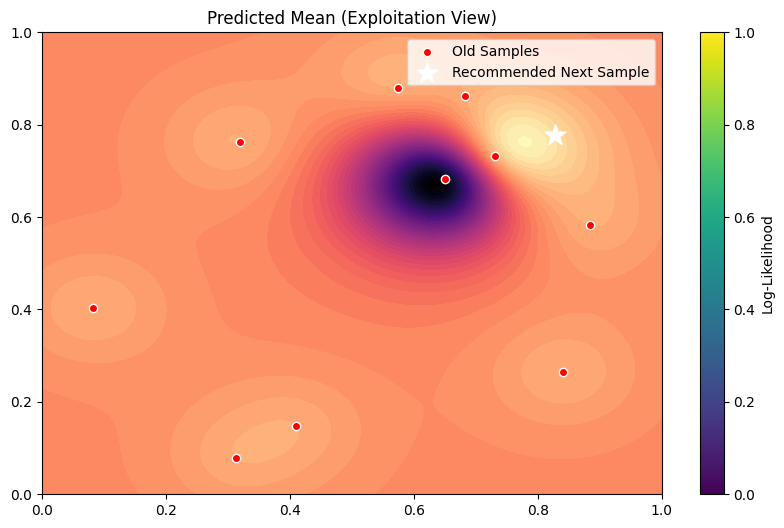

In [24]:
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, mu_map, levels=50, cmap='magma')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Old Samples')
plt.scatter(ucb_next_query[0], ucb_next_query[1], c='white', marker='*', s=250, label='Recommended Next Sample')
plt.title('Predicted Mean (Exploitation View)')
plt.colorbar(label='Log-Likelihood')
plt.legend()
plt.show()

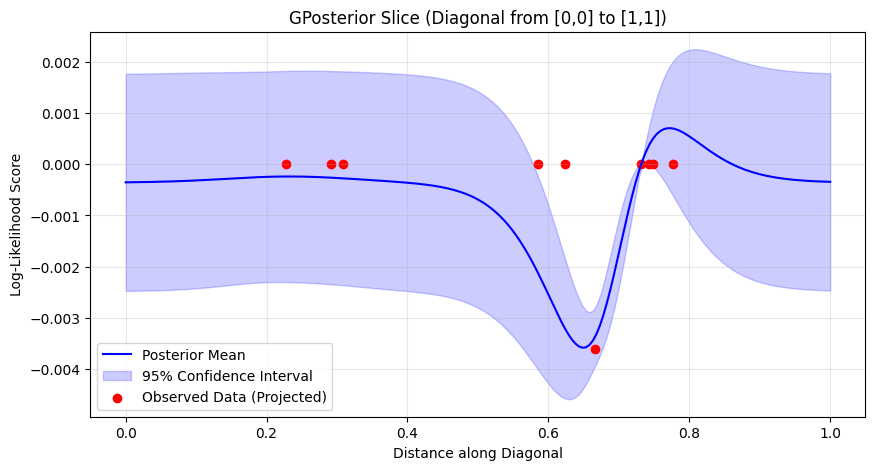

In [25]:
# Create a diagonal slice from [0,0] to [1,1]
n_points = 200
line_coords = np.linspace(0, 1, n_points)
X_slice = np.c_[line_coords, line_coords] # Diagonal slice

# Get mean and standard deviation from the Posterior
mu, sigma = gp.predict(X_slice, return_std=True)

plt.figure(figsize=(10, 5))

# Plot the Mean prediction
plt.plot(line_coords, mu, 'b-', label='Posterior Mean')

# Plot the Confidence Interval (95% confidence = 1.96 * sigma)
plt.fill_between(line_coords, 
                 mu - 1.96*sigma, 
                 mu + 1.96*sigma, 
                 alpha=0.2, color='blue', label='95% Confidence Interval')

# Project existing data points onto this diagonal (for visualization)
# We calculate their distance from [0,0] to place them on the X-axis
dist = np.sqrt(np.sum(X**2, axis=1)) / np.sqrt(2)
plt.scatter(dist, y, c='red', label='Observed Data (Projected)')

plt.title('GPosterior Slice (Diagonal from [0,0] to [1,1])')
plt.xlabel('Distance along Diagonal')
plt.ylabel('Log-Likelihood Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()